In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
!pip install transformers datasets scikit-learn

In [ ]:
import pandas as pd

df = pd.read_csv("Category.csv")
df.head()

,Unnamed: 0,category,language,likes,published_at,sentiment,subcategory,text,clean_text
0,0,Irony,Kenyan_slang,10,2025-07-28T16:36:04Z,Positive,Hyperbolic understatement,Napenda hii couple but hapo kwa 29yrs nimekata...,napenda hii couple but hapo kwa 29yrs nimekata...
1,1,Others,Kenyan_slang,0,2025-07-28T16:35:44Z,Neutral,General Others,rada zako wasingam,rada zako wasingam
2,2,Constructive,Kenyan_slang,0,2025-07-28T16:35:12Z,Positive,Genuine Praise,Izo chwom mbaya ndio zetuu😂😂,izo chwom mbaya ndio zetuu face_with_tears_of_...
3,3,Constructive,Kenyan_slang,0,2025-07-28T16:35:07Z,Positive,Genuine Praise,Nka shy😅,nka shy grinning_face_with_sweat
4,4,Constructive,Kenyan_slang,1,2025-07-28T16:34:43Z,Neutral,Decision-criticism,Ata kama ni dooh kuna shida zingine siwezi taka,ata kama ni dooh kuna shida zingine siwezi taka


In [ ]:
positive_df = df[df["sentiment"] == "Positive"]
neutral_df = df[df["sentiment"] == "Neutral"]
negative_df = df[df["sentiment"] == "Negative"]

In [ ]:
print(len(positive_df))
print(len(neutral_df))
print(len(negative_df))

2027
2296
1688


In [ ]:
neutral_df["label"] = neutral_df["category"].astype("category").cat.codes

neutral_df[["category","label"]].drop_duplicates()

/tmp/ipykernel_439/422814109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neutral_df["label"] = neutral_df["category"].astype("category").cat.codes


,category,label
1,Others,5
4,Constructive,0
5,Irony,3
180,Offensive,4
664,Cyberbullying,1
890,Harmful,2


In [ ]:
from sklearn.model_selection import train_test_split

neutral_train, neutral_test = train_test_split(
    neutral_df,
    test_size=0.2,
    stratify=neutral_df["label"],
    random_state=42
)

In [ ]:
negative_df["label"] = negative_df["category"].astype("category").cat.codes

negative_df[["category","label"]].drop_duplicates()

/tmp/ipykernel_439/2327058986.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_df["label"] = negative_df["category"].astype("category").cat.codes


,category,label
7,Irony,3
90,Cyberbullying,1
96,Offensive,4
129,Constructive,0
199,Others,5
244,Harmful,2


In [ ]:
negative_train, negative_test = train_test_split(
    negative_df,
    test_size=0.2,
    stratify=negative_df["label"],
    random_state=42
)

In [ ]:
from datasets import Dataset

neutral_train_ds = Dataset.from_pandas(
    neutral_train[["text","label"]].reset_index(drop=True)
)

neutral_test_ds = Dataset.from_pandas(
    neutral_test[["text","label"]].reset_index(drop=True)
)

negative_train_ds = Dataset.from_pandas(
    negative_train[["text","label"]].reset_index(drop=True)
)

negative_test_ds = Dataset.from_pandas(
    negative_test[["text","label"]].reset_index(drop=True)
)

In [ ]:
from datasets import Dataset

neutral_train_ds = Dataset.from_pandas(
    neutral_train[["text","label"]].reset_index(drop=True)
)

neutral_test_ds = Dataset.from_pandas(
    neutral_test[["text","label"]].reset_index(drop=True)
)

negative_train_ds = Dataset.from_pandas(
    negative_train[["text","label"]].reset_index(drop=True)
)

negative_test_ds = Dataset.from_pandas(
    negative_test[["text","label"]].reset_index(drop=True)
)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
neutral_train_ds = neutral_train_ds.map(tokenize, batched=True)
neutral_test_ds = neutral_test_ds.map(tokenize, batched=True)

negative_train_ds = negative_train_ds.map(tokenize, batched=True)
negative_test_ds = negative_test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/1836 [00:00<?, ? examples/s]

Map:   0%|          | 0/460 [00:00<?, ? examples/s]

Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

Map:   0%|          | 0/338 [00:00<?, ? examples/s]

In [ ]:
neutral_train_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])
neutral_test_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])

negative_train_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])
negative_test_ds.set_format(type="torch", columns=["input_ids","attention_mask","label"])

In [ ]:
from transformers import AutoModelForSequenceClassification

neutral_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=neutral_df["label"].nunique()
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
negative_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=negative_df["label"].nunique()
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5
)

In [ ]:
from transformers import Trainer

neutral_trainer = Trainer(
    model=neutral_model,
    args=training_args,
    train_dataset=neutral_train_ds,
    eval_dataset=neutral_test_ds
)

neutral_trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.942163
2,No log,0.926260
3,1.016139,0.930568
4,1.016139,0.925212
5,0.892417,0.925504


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1150, training_loss=0.9356307917055876, metrics={'train_runtime': 423.2412, 'train_samples_per_second': 21.69, 'train_steps_per_second': 2.717, 'total_flos': 603861558589440.0, 'train_loss': 0.9356307917055876, 'epoch': 5.0})

In [ ]:
negative_trainer = Trainer(
    model=negative_model,
    args=training_args,
    train_dataset=negative_train_ds,
    eval_dataset=negative_test_ds
)

negative_trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,1.587853
2,No log,1.544016
3,1.568216,1.550911
4,1.568216,1.574398
5,1.568216,1.567772


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=845, training_loss=1.5402855867464866, metrics={'train_runtime': 284.7804, 'train_samples_per_second': 23.702, 'train_steps_per_second': 2.967, 'total_flos': 444015851904000.0, 'train_loss': 1.5402855867464866, 'epoch': 5.0})

In [ ]:
neutral_predictions = neutral_trainer.predict(neutral_test_ds)
negative_predictions = negative_trainer.predict(negative_test_ds)

In [ ]:
import numpy as np

neutral_y_pred = np.argmax(neutral_predictions.predictions, axis=1)
neutral_y_true = neutral_predictions.label_ids

negative_y_pred = np.argmax(negative_predictions.predictions, axis=1)
negative_y_true = negative_predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

neutral_labels = neutral_df["category"].astype("category").cat.categories

print(classification_report(
    neutral_y_true,
    neutral_y_pred,
    target_names=neutral_labels
))

               precision    recall  f1-score   support

 Constructive       0.60      0.70      0.65       219
Cyberbullying       0.00      0.00      0.00         5
      Harmful       0.00      0.00      0.00         4
        Irony       0.00      0.00      0.00        18
    Offensive       0.00      0.00      0.00         4
       Others       0.63      0.61      0.62       210

     accuracy                           0.61       460
    macro avg       0.20      0.22      0.21       460
 weighted avg       0.57      0.61      0.59       460



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
negative_labels = negative_df["category"].astype("category").cat.categories

print(classification_report(
    negative_y_true,
    negative_y_pred,
    target_names=negative_labels
))

               precision    recall  f1-score   support

 Constructive       0.00      0.00      0.00        50
Cyberbullying       0.40      0.76      0.52       121
      Harmful       0.00      0.00      0.00        14
        Irony       0.33      0.42      0.37        81
    Offensive       0.33      0.02      0.04        50
       Others       0.00      0.00      0.00        22

     accuracy                           0.38       338
    macro avg       0.18      0.20      0.15       338
 weighted avg       0.27      0.38      0.28       338



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


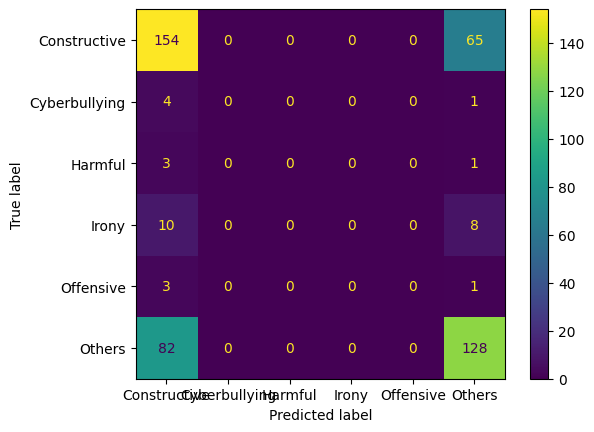

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(neutral_y_true, neutral_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=neutral_labels
)

disp.plot()
plt.show()

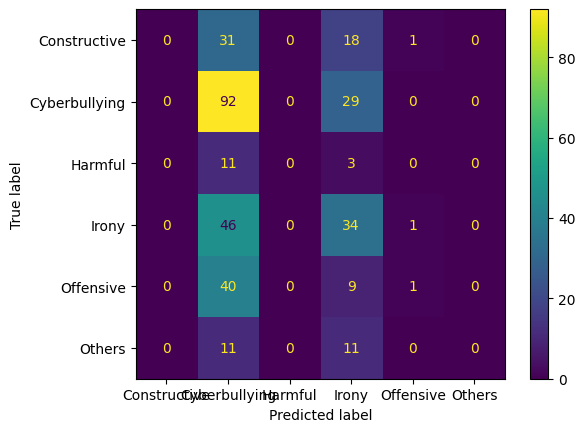

In [ ]:
cm = confusion_matrix(negative_y_true, negative_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=negative_labels
)

disp.plot()
plt.show()

In [ ]:
neutral_model.save_pretrained("neutral_category_model")
negative_model.save_pretrained("negative_category_model")

tokenizer.save_pretrained("category_tokenizer")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('category_tokenizer/tokenizer_config.json',
 'category_tokenizer/tokenizer.json')

In [ ]:
!zip -r cyberbullying_models.zip neutral_category_model negative_category_model category_tokenizer

  adding: neutral_category_model/ (stored 0%)
  adding: neutral_category_model/model.safetensors (deflated 31%)
  adding: neutral_category_model/config.json (deflated 55%)
  adding: negative_category_model/ (stored 0%)
  adding: negative_category_model/model.safetensors (deflated 31%)
  adding: negative_category_model/config.json (deflated 55%)
  adding: category_tokenizer/ (stored 0%)
  adding: category_tokenizer/tokenizer_config.json (deflated 47%)
  adding: category_tokenizer/tokenizer.json (deflated 77%)


In [ ]:
!ls

Category.csv		  negative_category_model  sample_data
category_tokenizer	  neutral_category_model
cyberbullying_models.zip  results


In [ ]:
from google.colab import files
files.download("cyberbullying_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!mv cyberbullying_models.zip /content/drive/MyDrive/

mv: cannot move 'cyberbullying_models.zip' to '/content/drive/MyDrive/': No such file or directory


In [ ]:
!ls /content/drive/MyDrive/

ls: cannot access '/content/drive/MyDrive/': No such file or directory


In [ ]:
!mv /content/cyberbullying_models.zip

mv: missing destination file operand after '/content/cyberbullying_models.zip'
Try 'mv --help' for more information.


In [ ]:
!mv /content/cyberbullying_models.zip /content/drive/MyDrive/

mv: cannot move '/content/cyberbullying_models.zip' to '/content/drive/MyDrive/': No such file or directory
